In [32]:
import gzip
import os
from pathlib import Path
import re

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from dna_features_viewer import GraphicFeature, GraphicRecord
from Bio import SeqIO, SeqRecord, Phylo

cwd = os.getcwd()
if cwd.endswith('bacteriocins'):
    os.chdir('../..')
    cwd = os.getcwd()

from src.tree.tree_util import prune_leaves_with_unknown_id
from src.tree.itol_annotation import itol_labels

In [33]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('data')
assert data_folder.is_dir()

subtilosin_A_folder = data_folder / 'amp_db' / 'Subtilosin_A'
assert subtilosin_A_folder.is_dir()

subtilosin_A_out = Path('data/outputs/amp_db/Subtilosin_A')


In [34]:
mmseqs_df = pd.read_csv(subtilosin_A_folder / 'wider_gtdb_search' / 'sboA_albA_albC_results.tsv', sep='\t')
mmseqs_df['domain'] = mmseqs_df['taxlineage'].apply(lambda v: v.split(';')[0].replace('d_', ''))
mmseqs_df['gtdb_phylum'] = mmseqs_df['taxlineage'].apply(lambda v: v.split(';')[1].replace('p_', ''))
mmseqs_df['gtdb_class'] = mmseqs_df['taxlineage'].apply(lambda v: v.split(';')[2].replace('c_', ''))
mmseqs_df['gtdb_order'] = mmseqs_df['taxlineage'].apply(lambda v: v.split(';')[3].replace('o_', ''))
mmseqs_df['gtdb_family'] = mmseqs_df['taxlineage'].apply(lambda v: v.split(';')[4].replace('f_', ''))
mmseqs_df['gtdb_genus'] = mmseqs_df['taxlineage'].apply(lambda v: v.split(';')[5].replace('g_', ''))
mmseqs_df['gtdb_species'] = mmseqs_df['taxlineage'].apply(lambda v: v.split(';')[6].replace('s_', ''))
mmseqs_df = mmseqs_df.drop(columns=['taxlineage'])

mmseqs_df = mmseqs_df.sort_values(['target', 'bits'], ascending=[True, False]).drop_duplicates(['target'])

sboA_like = ['NP_391616.1', 'WP_088863144.1', 'WP_042691590.1']
albA_like = ['NP_391617.1', 'WP_088863145.1', 'WP_042691587.1']
albC_like = ['NP_391619.1', 'WP_157895742.1', 'WP_051482183.1']

mmseqs_df['sboA'] = mmseqs_df['query'].isin(sboA_like)
mmseqs_df['albA'] = mmseqs_df['query'].isin(albA_like)
mmseqs_df['albC'] = mmseqs_df['query'].isin(albC_like)

mmseqs_df['contig_id'] = mmseqs_df['target'].apply(lambda v: re.match(r'^(.+\.[0-9]+)_[0-9]+$', v)[1])

mmseqs_df.to_csv(subtilosin_A_out / 'wider_gtdb_search' / 'Subtilosin_A_GTDB.csv', index=False)

mmseqs_df.head()

,query,target,evalue,bits,tstart,tend,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,sboA,albA,albC,contig_id
3740,WP_157895742.1,AOIR01000063.1_73,3.288000e-78,270,8,236,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,False,False,True,AOIR01000063.1
140,NP_391617.1,AP017647.1_99,9.654000e-35,152,124,433,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanothermobacteraceae A,Methanothermobacter A,Methanothermobacter A sp003584625,False,True,False,AP017647.1
4386,WP_042691587.1,AP024710.1_2828,1.021000e-17,99,140,307,Bacteria,Chloroflexota,Anaerolineae,Anaerolineales,Anaerolineaceae,Leptolinea,Leptolinea sp012798615,False,True,False,AP024710.1
4057,WP_042691587.1,ASPF01000032.1_15,1.907000e-30,139,143,418,Archaea,Thermoproteota,Nitrososphaeria A,Caldarchaeales,Wolframiiraptoraceae,Geocrenenecus,Geocrenenecus sp000405685,False,True,False,ASPF01000032.1
664,NP_391617.1,ATMD01000002.1_311,1.443000e-67,249,127,413,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825,False,True,False,ATMD01000002.1


In [35]:
df = mmseqs_df[mmseqs_df['sboA']]

pd.DataFrame(
    df[
        df['domain'] == 'Archaea'
    ][['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species']].value_counts(), 
    columns=['count'],
).sort_values(['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species'])

count
domain  gtdb_phylum         gtdb_genus   gtdb_species                 
Archaea Methanobacteriota B Thermococcus Thermococcus celer          1
                                         Thermococcus henrietii      1
                                         Thermococcus nautili        1

### More than one match?

In [36]:
df = mmseqs_df[['contig_id', 'sboA', 'albA', 'albC']].groupby('contig_id').any()

df['total'] = df['sboA'].astype(int) + df['albA'].astype(int) + df['albC'].astype(int)
contigs_with_two_matches_or_more = sorted(set(df[df['total'] > 1].index))

relevant_hits = mmseqs_df[
    mmseqs_df['contig_id'].isin(contigs_with_two_matches_or_more)
].copy()

pd.DataFrame(
    relevant_hits[
        relevant_hits['domain'] == 'Archaea'
    ][['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species']].value_counts(), 
    columns=['count'],
).sort_values(['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species'])

count
domain  gtdb_phylum         gtdb_genus   gtdb_species                    
Archaea Asgardarchaeota     Hodarchaeum  Hodarchaeum sp020353515        3
        Halobacteriota      Halostella   Halostella litorea             2
        Methanobacteriota B Pyrococcus   Pyrococcus kukulkanii          2
                            Thermococcus Thermococcus celer             4
                                         Thermococcus henrietii         4
                                         Thermococcus nautili           3
        Thermoproteota      Caldivirga   Caldivirga maquilingensis      2

In [37]:
df = mmseqs_df[['contig_id', 'sboA', 'albA', 'albC']].groupby('contig_id').any()

df['total'] = df['sboA'].astype(int) + df['albA'].astype(int) + df['albC'].astype(int)
contigs_with_two_matches_or_more = sorted(set(df[df['total'] >= 3].index))

relevant_hits_3 = mmseqs_df[
    mmseqs_df['contig_id'].isin(contigs_with_two_matches_or_more)
].copy()

pd.DataFrame(
    relevant_hits_3[
        relevant_hits_3['domain'] == 'Archaea'
    ][['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species']].value_counts(), 
    columns=['count'],
).sort_values(['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species'])

count
domain  gtdb_phylum         gtdb_genus   gtdb_species                 
Archaea Methanobacteriota B Thermococcus Thermococcus celer          4
                                         Thermococcus henrietii      4
                                         Thermococcus nautili        3

In [38]:
pd.DataFrame(
    relevant_hits_3[
        relevant_hits_3['domain'] == 'Bacteria'
    ][['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species']].value_counts(), 
    columns=['count'],
).sort_values(['domain', 'gtdb_phylum', 'gtdb_genus', 'gtdb_species'])

count
domain   gtdb_phylum gtdb_genus           gtdb_species                            
Bacteria Bacillota   Aneurinibacillus     Aneurinibacillus thermoaerophilus      3
                     Bacillus             Bacillus atrophaeus                    3
                                          Bacillus cabrialesii                   3
                                          Bacillus halotolerans                  3
                                          Bacillus inaquosorum                   3
                                          Bacillus mojavensis                    3
                                          Bacillus spizizenii                    3
                                          Bacillus subtilis                      3
                                          Bacillus subtilis G                    3
                                          Bacillus tequilensis                   3
                     Bacillus O           Bacillus O smithii                     3
                     Enterococcus A       Enterococcus A devriesei               5
                     Lysinibacillus       Lysinibacillus contaminans             3
                     Paenibacillus        Paenibacillus sp024159265              3
                     Quasibacillus        Quasibacillus thermotolerans           4
                     Staphylococcus       Staphylococcus agnetis                 3
                                          Staphylococcus delphini                3
                                          Staphylococcus felis                   3
         Bacillota A Caldicellulosiruptor Caldicellulosiruptor danielii          3

In [39]:
mmseqs_df[mmseqs_df['gtdb_species'] == 'Pyrococcus kukulkanii']

,query,target,evalue,bits,tstart,tend,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,sboA,albA,albC,contig_id
3012,WP_157895742.1,NZ_CP010835.1_1113,1.134000e-40,161,23,229,Archaea,Methanobacteriota B,Thermococci,Thermococcales,Thermococcaceae,Pyrococcus,Pyrococcus kukulkanii,False,False,True,NZ_CP010835.1
4142,WP_042691587.1,NZ_CP010835.1_2138,1.977000e-25,123,168,351,Archaea,Methanobacteriota B,Thermococci,Thermococcales,Thermococcaceae,Pyrococcus,Pyrococcus kukulkanii,False,True,False,NZ_CP010835.1


## Gene context

In [40]:
def parse_gff(path : Path):
    gff_csv = pd.read_csv(
        path,
        sep='\t',
        comment='#',
        header=None,
        names=[
            'contig_id',
            'source',
            'type',
            'start',
            'end',
            'na1',
            'strand',
            'na2',
            'metadata',
        ],
    )

    def parse_protein_id(metadata : str):
        m = re.match(r'^.*protein_id=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None
        
    def parse_description(metadata : str):
        m = re.match(r'^.*product=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None

    gff_csv = gff_csv[gff_csv['type'] == 'CDS'].reset_index(drop=True)
    gff_csv['protein_id'] = gff_csv['metadata'].apply(parse_protein_id)
    gff_csv['description'] = gff_csv['metadata'].apply(parse_description)

    return gff_csv.drop_duplicates(['contig_id', 'protein_id']).reset_index(drop=True).set_index('protein_id')


In [41]:
def get_context(gff_df, core_protein_id, n_upstream=9_000, n_downstream=9_000):
    gff_row = gff_df.loc[core_protein_id]

    contig_id = gff_row['contig_id']
    start = max(gff_row['start'] - n_upstream, 1)
    end = gff_row['end'] + n_downstream

    return gff_df[
        (gff_df['contig_id'] == contig_id) &
        (gff_df['start'] >= start) &
        (gff_df['start'] < end) &
        (gff_df['end'] > start) &
        (gff_df['end'] <= end)
    ].copy()

In [42]:
def plot_genes(aoi_df, color_map=None, label_map=None, ax=None, figure_width=20, no_labels=False, default_color='#cccccc'):
    features = []
    start = aoi_df['start'].min()
    end = aoi_df['end'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        if no_labels:
            label = None
        elif label_map is not None:
            label = label_map[row.name]
        else:
            label = row['description']
    
        if color_map is not None and row.name in color_map:
            color = color_map[row.name]
        else:
            color = default_color

        features.append(
            GraphicFeature(
                start=row.start, 
                end=row.end, 
                strand=1 if row.strand == '+' else -1, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

### Pyrococcus furiosus

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_011013203.1,NC_003413.1,Protein Homology,CDS,1896268,1896744,.,-,0,ID=cds-WP_011013203.1;Parent=gene-PF_RS10410;D...,30S ribosomal protein S15
WP_011013204.1,NC_003413.1,GeneMarkS-2+,CDS,1897201,1897371,.,-,0,ID=cds-WP_011013204.1;Parent=gene-PF_RS11255;D...,hypothetical protein
WP_011013205.1,NC_003413.1,Protein Homology,CDS,1897530,1897727,.,-,0,ID=cds-WP_011013205.1;Parent=gene-PF_RS10420;D...,DUF104 domain-containing protein
WP_223208988.1,NC_003413.1,Protein Homology,CDS,1898123,1899577,.,-,0,ID=cds-WP_223208988.1;Parent=gene-PF_RS10425;D...,M1 family aminopeptidase
WP_011013207.1,NC_003413.1,Protein Homology,CDS,1899840,1900433,.,-,0,ID=cds-WP_011013207.1;Parent=gene-PF_RS10430;D...,SPASM domain-containing protein
WP_014835502.1,NC_003413.1,Protein Homology,CDS,1900616,1901209,.,-,0,ID=cds-WP_014835502.1;Parent=gene-PF_RS10435;D...,radical SAM protein
WP_014835501.1,NC_003413.1,Protein Homology,CDS,1901582,1902394,.,+,0,ID=cds-WP_014835501.1;Parent=gene-PF_RS10440;D...,ABC transporter permease
WP_011013210.1,NC_003413.1,Protein Homology,CDS,1902398,1902682,.,+,0,ID=cds-WP_011013210.1;Parent=gene-PF_RS10445;D...,MarR family transcriptional regulator
WP_011013211.1,NC_003413.1,Protein Homology,CDS,1902688,1904442,.,-,0,ID=cds-WP_011013211.1;Parent=gene-PF_RS10450;D...,M1 family aminopeptidase


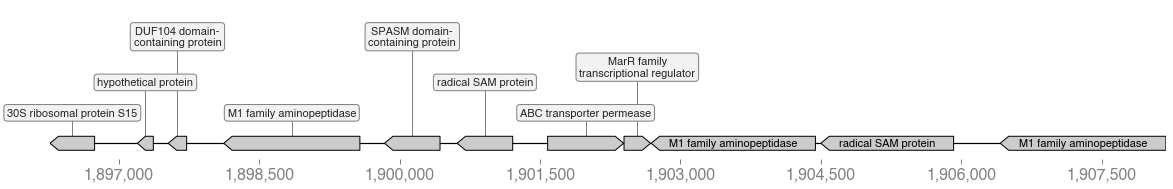

In [43]:
p_furiosus_accession = 'GCF_000007305.1'
p_furiosus_radical_sam = 'WP_011013207.1'


P_furiosus_gff_path = subtilosin_A_folder / 'Pyrococcus furiosus' / 'GCF_000007305.1_ASM730v1_genomic.gff.gz'

P_furiosus_gff = parse_gff(P_furiosus_gff_path)
p_furiosus_rsam_context = get_context(P_furiosus_gff, p_furiosus_radical_sam, n_upstream=5_000, n_downstream=20_000)

plot_genes(p_furiosus_rsam_context);

p_furiosus_rsam_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_068322006.1,NZ_CP010835.1,Protein Homology,CDS,1015042,1017216,.,+,0,ID=cds-WP_068322006.1;Parent=gene-TQ32_RS05415...,methionine--tRNA ligase
WP_068322007.1,NZ_CP010835.1,Protein Homology,CDS,1017394,1018245,.,+,0,ID=cds-WP_068322007.1;Parent=gene-TQ32_RS05420...,sulfide/dihydroorotate dehydrogenase-like FAD/...
WP_068322008.1,NZ_CP010835.1,Protein Homology,CDS,1018246,1019673,.,+,0,ID=cds-WP_068322008.1;Parent=gene-TQ32_RS05425...,NADPH-dependent glutamate synthase
WP_068322011.1,NZ_CP010835.1,Protein Homology,CDS,1019726,1020031,.,-,0,ID=cds-WP_068322011.1;Parent=gene-TQ32_RS05430...,divalent-cation tolerance protein CutA
WP_068322014.1,NZ_CP010835.1,Protein Homology,CDS,1020028,1021191,.,-,0,ID=cds-WP_068322014.1;Parent=gene-TQ32_RS05435...,NMD3-related protein
WP_068322015.1,NZ_CP010835.1,Protein Homology,CDS,1021232,1022035,.,-,0,ID=cds-WP_068322015.1;Parent=gene-TQ32_RS05440...,winged helix-turn-helix transcriptional regulator
WP_068322016.1,NZ_CP010835.1,Protein Homology,CDS,1022032,1023129,.,-,0,ID=cds-WP_068322016.1;Parent=gene-TQ32_RS05445...,hypothetical protein
WP_227805058.1,NZ_CP010835.1,Protein Homology,CDS,1023177,1024088,.,+,0,ID=cds-WP_227805058.1;Parent=gene-TQ32_RS05450...,ATP-binding cassette domain-containing protein
WP_068322019.1,NZ_CP010835.1,Protein Homology,CDS,1024085,1024750,.,+,0,ID=cds-WP_068322019.1;Parent=gene-TQ32_RS05455...,ABC transporter permease


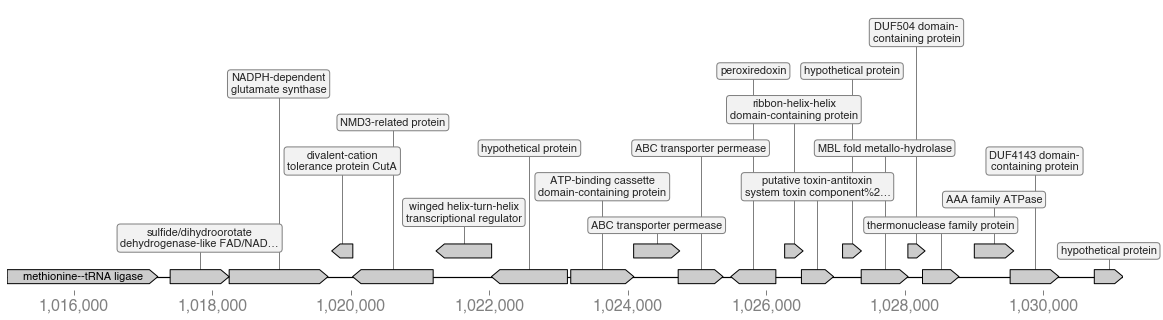

In [44]:
p_kukulkanii_accession = 'GCF_001577775.1'
p_kukulkanii_protein = 'WP_227805058.1'
# p_kukulkanii_protein = 'WP_068324828.1'

P_kukulkanii_gff_path = subtilosin_A_folder / 'Pyrococcus kukulkanii' / 'GCF_001577775.1_ASM157777v1_genomic.gff.gz'

p_kukulkanii_gff = parse_gff(P_kukulkanii_gff_path)
p_kukulkanii_context = get_context(p_kukulkanii_gff, p_kukulkanii_protein)

plot_genes(p_kukulkanii_context);

p_kukulkanii_context

## Thermococcus tree

In [45]:
gtdb_archaea = pd.read_csv(data_folder / 'gtdb_r214.1' / 'ar53_metadata_r214.tsv', sep='\t', index_col='accession')

In [46]:
arc_tree = Phylo.read(data_folder / 'gtdb_r214.1' / 'ar53_r214.tree', 'newick')

thermococcus_ids = set(gtdb_archaea[
    gtdb_archaea['gtdb_taxonomy'].str.contains('s__Thermococcus') &
    (gtdb_archaea['gtdb_representative'] == 't')
].index)

thermococcus_tree = prune_leaves_with_unknown_id(arc_tree, thermococcus_ids)

assert len(thermococcus_tree.get_terminals()) == len(thermococcus_ids)

Phylo.write([thermococcus_tree], (subtilosin_A_out / 'thermococcus_all.tree').as_posix(), 'newick')

1

In [47]:
thermococcus_labels = []
for leaf in thermococcus_tree.get_terminals():
    accession = leaf.name
    species_name = gtdb_archaea.loc[accession, 'gtdb_taxonomy'].split(';')[-1].replace('s__', '')
    thermococcus_labels.append([accession, species_name])

itol_labels(thermococcus_labels, subtilosin_A_out / 'thermococcus_all_labels.txt')

In [48]:
named_thermococcus_ids = set(gtdb_archaea[
    gtdb_archaea['gtdb_taxonomy'].str.contains(r';g__Thermococcus;', regex=True) &
    ~gtdb_archaea['gtdb_taxonomy'].str.contains(r's__Thermococcus sp\d+', regex=True) &
    (gtdb_archaea['gtdb_representative'] == 't')
].index)

named_thermococcus_tree = prune_leaves_with_unknown_id(arc_tree, named_thermococcus_ids)

assert len(named_thermococcus_tree.get_terminals()) == len(named_thermococcus_ids)

Phylo.write([named_thermococcus_tree], (subtilosin_A_out / 'thermococcus_named.tree').as_posix(), 'newick')

named_thermococcus_labels = []
for leaf in named_thermococcus_tree.get_terminals():
    accession = leaf.name
    species_name = gtdb_archaea.loc[accession, 'gtdb_taxonomy'].split(';')[-1].replace('s__', '')
    named_thermococcus_labels.append([accession, species_name])

itol_labels(named_thermococcus_labels, subtilosin_A_out / 'thermococcus_named_labels.txt')

len(named_thermococcus_ids)

23